<a href="https://colab.research.google.com/github/andy1680303/machine_learnig_project_2/blob/main/breast_cancer_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##資料解釋（打預防針，各位點進來請先看）

此資料是搜集病人的乳癌資料，並列出每個腫瘤的特徵以及診斷結果，將這些資料用以訓練機器學習。

嗯...相信你們看到這些資料會覺得很熟悉，因為這根本是課堂上示範的資料嘛！相信我，在我們組員挑選資料時也沒有想到會剛好選到示範資料。一開始是想捨棄改用其他份的，但想想又覺得雖然資料相同，但重要的應該是呈現清楚的資料故事，這也是課堂上老師沒有著墨到的。

當然，程式也不是全然複製貼上，請各位認真看完喔！

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##資料特徵

此份資料為病人乳癌細胞的相關特徵，以下統一做解釋：

1. dignosis : 診斷結果，有良性惡性之分。
2. radius : 癌細胞半徑
3. texture : 癌細胞紋理，也就是灰階值，用來評估腫瘤組織特性、密度以及初步分辨良惡性的重要量化指標。
4. perimeter : 癌細胞周長
5. area : 癌細胞面積
6. smoothness : 癌細胞平滑度
7. compactness : 癌細胞緻密度（perimeter^2 / area - 1.0），可用來反應腫瘤形狀。
8. concavity : 癌細胞凹陷程度
9. concave points : 癌細胞邊界上的凹陷數量
10. symmetry : 癌細胞的對稱性，正常細胞通常較對稱。
11. fractal_dimension : 描述癌細胞邊界複雜程度。

此研究將以上2-11點的腫瘤特徵量化，並提供診斷結果，以供機器學習。

此外，每一項腫瘤特徵皆以 means、se 和 worst等變項呈現，其中：

means : 平均值，也就是患者好幾顆腫瘤的同一特徵取平均。

se : 標準差

worst : 患者乳癌細胞中最大顆的觀測值。



#匯入資料

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/程式設計/data.csv")
df=df.drop(['id','Unnamed: 32'],axis=1)
X=df.drop(['diagnosis'],axis=1)
y=df['diagnosis'].map({'M':1,'B':0})
feature_names = X.columns
print(f"資料X的shape: {X.shape}")
print(f"分類Y的shape: {y.shape}")
print(f"惡性(正類)類別的樣本數量: {np.where(y == 1)[0].size}")
print(f"良性(負類)類別的樣本數量: {np.where(y == 0)[0].size}")


資料X的shape: (569, 30)
分類Y的shape: (569,)
惡性(正類)類別的樣本數量: 212
良性(負類)類別的樣本數量: 357


##資料切分

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1234)
print(f"訓練集的資料X_train的shape: {X_train.shape}")
print(f"測試集的資料X_test的shape: {X_test.shape}")


訓練集的資料X_train的shape: (455, 30)
測試集的資料X_test的shape: (114, 30)


#零、資料前處理


##1.RECEV進行資料篩選

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
logistic_regressor = LogisticRegression(random_state=7890, max_iter=5000)
model = logistic_regressor


rfe_cv = RFECV(estimator=model, step=1, min_features_to_select=5, cv=5)
X_rfecv_train = rfe_cv.fit_transform(X_train, y_train)
rfe_cv_features=feature_names[rfe_cv.get_support()]
print(f"篩選後的資料shape: {X_rfecv_train.shape} ")
print(f"最後選出來的特徵數量：{rfe_cv.get_support().sum()}")
print(f"篩選特徵列表：{feature_names[rfe_cv.get_support()]}")

篩選後的資料shape: (455, 14) 
最後選出來的特徵數量：14
篩選特徵列表：Index(['radius_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'texture_se', 'perimeter_se',
       'radius_worst', 'texture_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst'],
      dtype='object')


##2.Sequential Feature Selection

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

logit_model = LogisticRegression(max_iter=5000, random_state=5678)

sfs = SequentialFeatureSelector(estimator=logit_model,
                                n_features_to_select=10,
                                direction="forward",
                                cv=5)
X_sfs_train = sfs.fit_transform(X_train, y_train)
sfs_features=feature_names[sfs.get_support()]

print(f"最後選出來的特徵數量：{sfs.get_support().sum()}")
print(f"篩選特徵列表：{feature_names[sfs.get_support()]}")

最後選出來的特徵數量：10
篩選特徵列表：Index(['radius_mean', 'perimeter_mean', 'smoothness_mean', 'compactness_mean',
       'concavity_mean', 'texture_worst', 'perimeter_worst', 'area_worst',
       'compactness_worst', 'concavity_worst'],
      dtype='object')


#一、監督式學習

## 1.Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_regressor = LogisticRegression(random_state=7890, max_iter=5000)
logistic_regressor.fit(X_train, y_train)
print(f'訓練好的係數(coefficient): \n {logistic_regressor.coef_}')
print(f"訓練好的係數個數：{logistic_regressor.coef_.size}")
print(f'訓練好的截距(intercept): \n {logistic_regressor.intercept_}')
training_performance = logistic_regressor.score(X_train, y_train)
print(f"使用訓練集進行預測的準確率：{training_performance}")
testing_performance = logistic_regressor.score(X_test, y_test)
print(f"使用測試集進行預測的準確率：{testing_performance}")

訓練好的係數(coefficient): 
 [[-0.9056484  -0.20613792  0.30503247 -0.02624709  0.1680791   0.22058467
   0.49388     0.23543058  0.20917175  0.02787931  0.01407768 -1.38552028
  -0.21486163  0.11880182  0.02533351 -0.04493582  0.05473737  0.02951101
   0.01181558 -0.00910241 -0.1306494   0.47176169  0.14198812  0.01228172
   0.35699599  0.70064988  1.38822517  0.49550004  0.55532153  0.10255394]]
訓練好的係數個數：30
訓練好的截距(intercept): 
 [-33.46952313]
使用訓練集進行預測的準確率：0.9604395604395605
使用測試集進行預測的準確率：0.9473684210526315


##1(a). RECEV+Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_regressor = LogisticRegression(random_state=7890, max_iter=5000)
logistic_regressor.fit(X_train[rfe_cv_features], y_train)
print(f'訓練好的係數(coefficient): \n {logistic_regressor.coef_}')
print(f"訓練好的係數個數：{logistic_regressor.coef_.size}")
print(f'訓練好的截距(intercept): \n {logistic_regressor.intercept_}')
training_performance = logistic_regressor.score(X_train[rfe_cv_features], y_train)
print(f"使用訓練集進行預測的準確率：{training_performance}")
testing_performance = logistic_regressor.score(X_test[rfe_cv_features], y_test)
print(f"使用測試集進行預測的準確率：{testing_performance}")

訓練好的係數(coefficient): 
 [[-0.87477699  0.45741817  0.79640407  0.35199591  0.27950749 -1.03794243
   0.97194681  1.75245129  0.2837752   0.44051971  1.30613819  2.18166637
   0.6942635   0.60597248]]
訓練好的係數個數：14
訓練好的截距(intercept): 
 [-26.80067038]
使用訓練集進行預測的準確率：0.9560439560439561
使用測試集進行預測的準確率：0.9473684210526315


## 1(b). Sequential Feature Selection+Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_regressor = LogisticRegression(random_state=7890, max_iter=5000)
logistic_regressor.fit(X_train[sfs_features], y_train)
print(f'訓練好的係數(coefficient): \n {logistic_regressor.coef_}')
print(f"訓練好的係數個數：{logistic_regressor.coef_.size}")
print(f'訓練好的截距(intercept): \n {logistic_regressor.intercept_}')
training_performance = logistic_regressor.score(X_train[sfs_features], y_train)
print(f"使用訓練集進行預測的準確率：{training_performance}")
testing_performance = logistic_regressor.score(X_test[sfs_features], y_test)
print(f"使用測試集進行預測的準確率：{testing_performance}")

訓練好的係數(coefficient): 
 [[-1.92955428  0.09245885  0.24831093  0.45573097  0.72955483  0.21740236
   0.17381986  0.01199736  1.00618263  1.55808337]]
訓練好的係數個數：10
訓練好的截距(intercept): 
 [-16.74708152]
使用訓練集進行預測的準確率：0.9604395604395605
使用測試集進行預測的準確率：0.9473684210526315


##2.KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=20)

knn_clf.fit(X_train, y_train)


print(f"使用訓練集的準確率: {knn_clf.score(X_train, y_train)}")
print(f"使用測試集的準確率: {knn_clf.score(X_test, y_test)}")


使用訓練集的準確率: 0.9296703296703297
使用測試集的準確率: 0.9298245614035088


##3.樸素貝式分類器 (Naive Bayes Classifier)

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb_clf = GaussianNB()

gnb_clf.fit(X_train, y_train)
print(f"使用訓練集的準確率: {gnb_clf.score(X_train, y_train)}")
print(f"使用測試集的準確率: {gnb_clf.score(X_test, y_test)}")

使用訓練集的準確率: 0.9494505494505494
使用測試集的準確率: 0.9035087719298246


##4.決策樹分類器 DecisionTreeClassifier

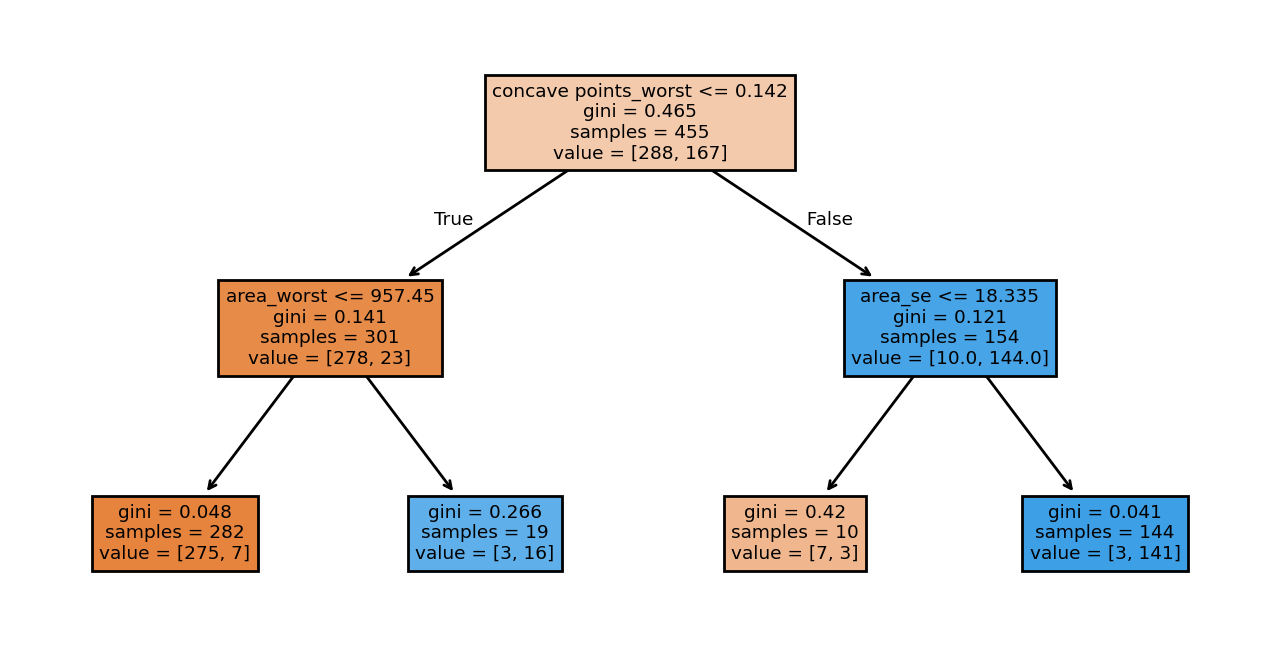

In [ ]:
feature_names = X.columns

from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(max_depth=2, random_state=5678)
decision_tree.fit(X_train, y_train)


from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4), dpi=200)
plot_tree(decision_tree, feature_names=feature_names, filled=True)
plt.show()

In [ ]:
training_accuracy = decision_tree.score(X_train, y_train)
print(f"對訓練集的分類準確率: {training_accuracy}")

testing_accuracy = decision_tree.score(X_test, y_test)
print(f"對測試集的分類準確率: {testing_accuracy}")

對訓練集的分類準確率: 0.9648351648351648
對測試集的分類準確率: 0.9210526315789473


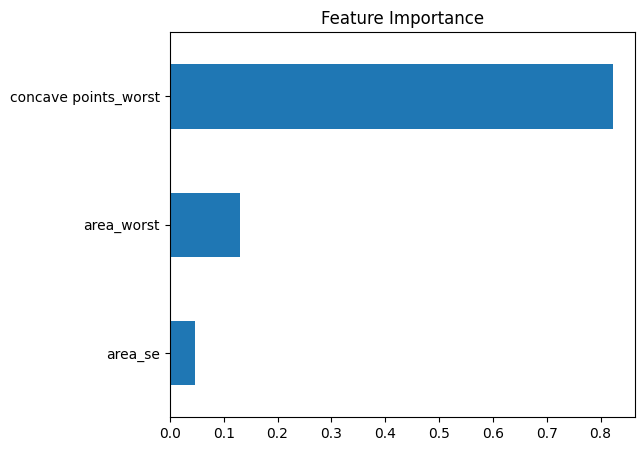

In [ ]:
import pandas as pd
feature_importances = decision_tree.feature_importances_

feature_series = pd.Series(feature_importances, index=feature_names)
feature_series = feature_series[feature_series > 0].sort_values(ascending=True)
ax = feature_series.plot(kind='barh', figsize=(6, 5), title="Feature Importance")

##5.隨機叢林

In [ ]:
from sklearn.ensemble import RandomForestClassifier


random_forest = RandomForestClassifier(max_depth=2, n_estimators=10, random_state=5678)
random_forest.fit(X_train, y_train)

print(f"對訓練集的分類準確率: {random_forest.score(X_train, y_train)}")
print(f"對測試集的分類準確率: {random_forest.score(X_test, y_test)}")

對訓練集的分類準確率: 0.9714285714285714
對測試集的分類準確率: 0.9035087719298246


特徵重要性: [0.08658479 0.         0.         0.         0.00714448 0.00263231
 0.0724313  0.19573945 0.         0.         0.00476911 0.00412718
 0.         0.         0.         0.         0.         0.03064783
 0.         0.         0.09964659 0.01044302 0.15969024 0.11057879
 0.         0.01266517 0.00115354 0.18907005 0.01267613 0.        ]
重要性非0的特徵: Index(['radius_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'radius_se', 'texture_se', 'concave points_se',
       'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst'],
      dtype='object') 
非0特徵重要性數值：[0.08658479 0.00714448 0.00263231 0.0724313  0.19573945 0.00476911
 0.00412718 0.03064783 0.09964659 0.01044302 0.15969024 0.11057879
 0.01266517 0.00115354 0.18907005 0.01267613]
重要性非0的特徵（由大到小）: Index(['concave points_mean', 'concave points_worst', 'perimeter_worst',
       'area_worst

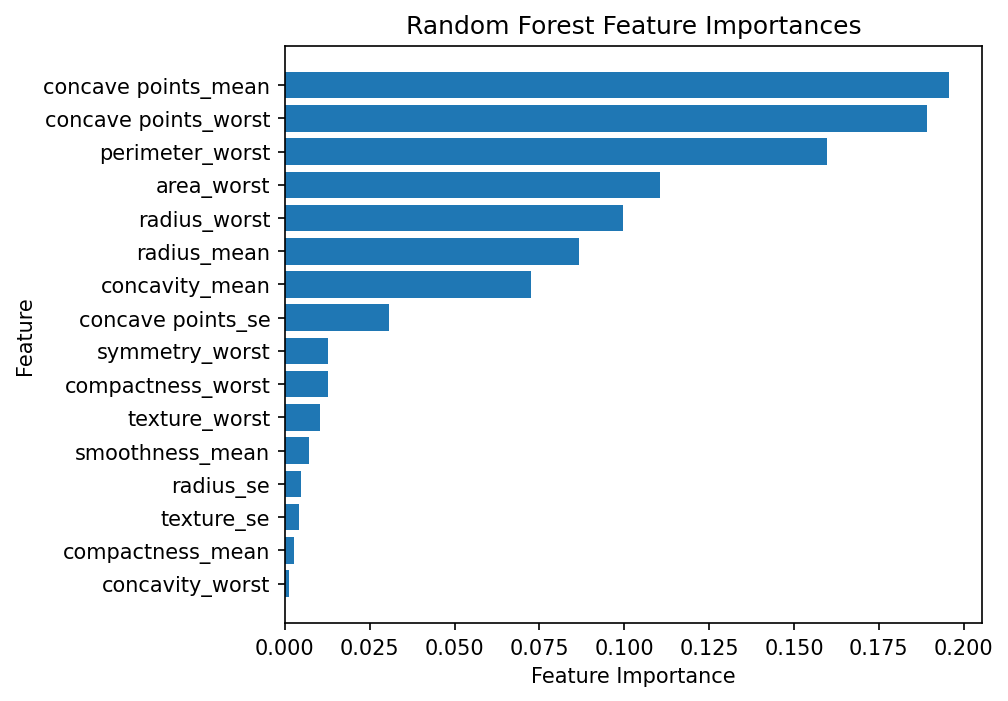

In [ ]:
feature_importances = random_forest.feature_importances_
print(f"特徵重要性: {feature_importances}")


print(f"重要性非0的特徵: {feature_names[np.where(feature_importances > 0)]} ")
print(f"非0特徵重要性數值：{feature_importances[np.where(feature_importances > 0)]}")


nonzero_idx = np.where(feature_importances > 0)[0]
sorted_idx = nonzero_idx[np.argsort(feature_importances[nonzero_idx])[::-1]]
sorted_features = feature_names[sorted_idx]
sorted_importances = feature_importances[sorted_idx]
print(f"重要性非0的特徵（由大到小）: {sorted_features}")
print(f"非0特徵重要性數值（由大到小）: {sorted_importances}")



fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
ax.barh(sorted_features, sorted_importances)
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title("Random Forest Feature Importances")
ax.invert_yaxis()
fig.show()

[DecisionTreeClassifier(max_depth=2, max_features='sqrt',
                        random_state=2101643380),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt', random_state=26474647),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt', random_state=254830910),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt', random_state=641653650),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt',
                        random_state=1572827455),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt', random_state=217090236),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt', random_state=81026445),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt',
                        random_state=1910042877),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt', random_state=421873188),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt',
                        random_state=1466012603)]

[DecisionTreeClassifier(max_depth=2, max_features='sqrt',
                       random_state=2101643380), DecisionTreeClassifier(max_depth=2, max_features='sqrt', random_state=26474647), DecisionTreeClassifier(max_depth=2, max_features='sqrt', random_state=254830910), DecisionTreeClassifier(max_depth=2, max_features='sqrt', random_state=641653650), DecisionTreeClassifier(max_depth=2, max_features='sqrt',
                       random_state=1572827455), DecisionTreeClassifier(max_depth=2, max_features='sqrt', random_state=217090236), DecisionTreeClassifier(max_depth=2, max_features='sqrt', random_state=81026445), DecisionTreeClassifier(max_depth=2, max_features='sqrt',
                       random_state=1910042877), DecisionTreeClassifier(max_depth=2, max_features='sqrt', random_state=421873188), DecisionTreeClassifier(max_depth=2, max_features='sqrt',
                       random_state=1466012603)]


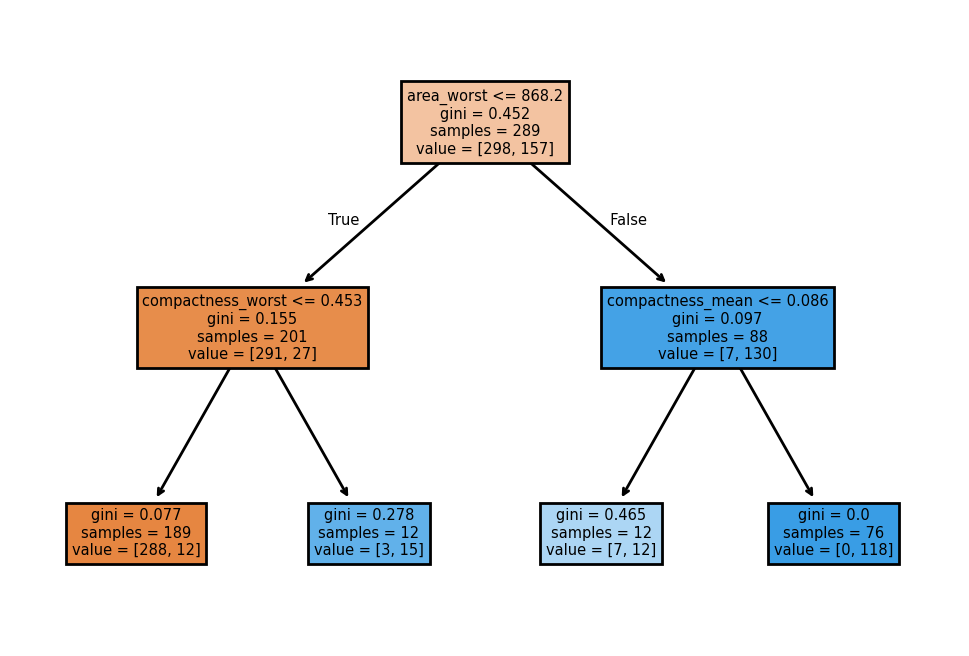

In [ ]:
display(random_forest.estimators_)
print(random_forest.estimators_)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4), dpi=200)
plot_tree(random_forest.estimators_[0], feature_names=feature_names, filled=True)
plt.show()



##6.支援向量機(SVC)

In [ ]:
from sklearn.svm import SVC
svc_model = SVC(C=10, kernel='linear', probability=True)
svc_model.fit(X_train, y_train)
svc_model.support_vectors_
svc_model.predict(X_test)
svc_model.predict_proba(X_test)
print(f"對訓練集的分類準確率: {svc_model.score(X_train, y_train)}")
print(f"對測試集的分類準確率: {svc_model.score(X_test, y_test)}" )

對訓練集的分類準確率: 0.9758241758241758
對測試集的分類準確率: 0.9385964912280702


## 7.ROC curve

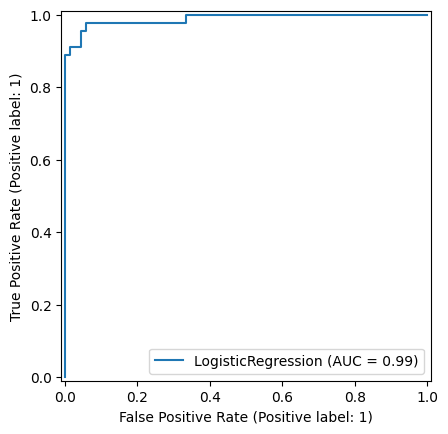

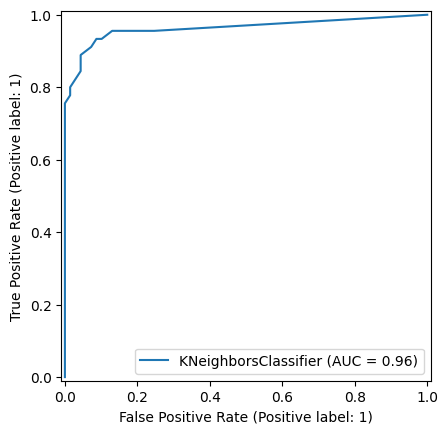

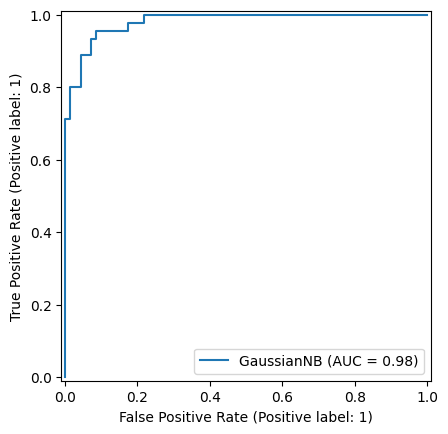

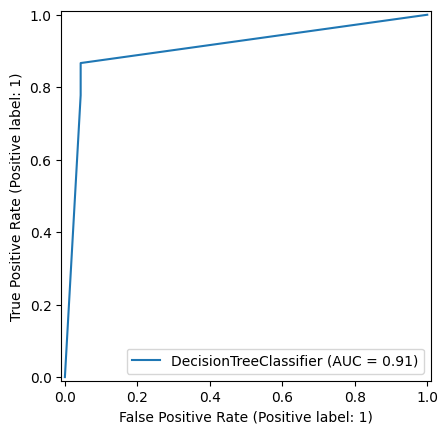

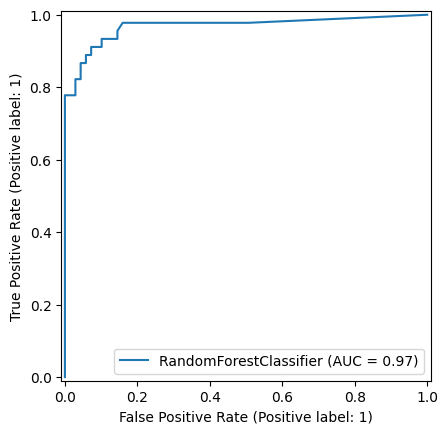

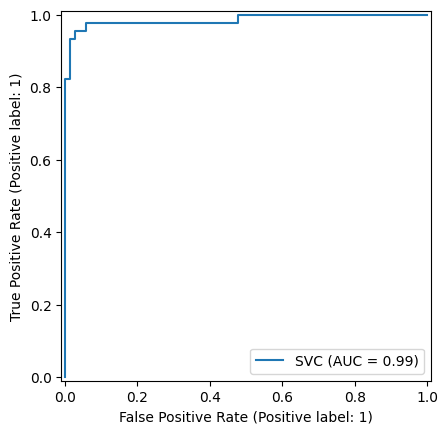

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(logistic_regressor, X_test, y_test)
RocCurveDisplay.from_estimator(knn_clf, X_test, y_test)
RocCurveDisplay.from_estimator(gnb_clf, X_test, y_test)
RocCurveDisplay.from_estimator(decision_tree, X_test, y_test)
RocCurveDisplay.from_estimator(random_forest, X_test, y_test)
RocCurveDisplay.from_estimator(svc_model, X_test, y_test)

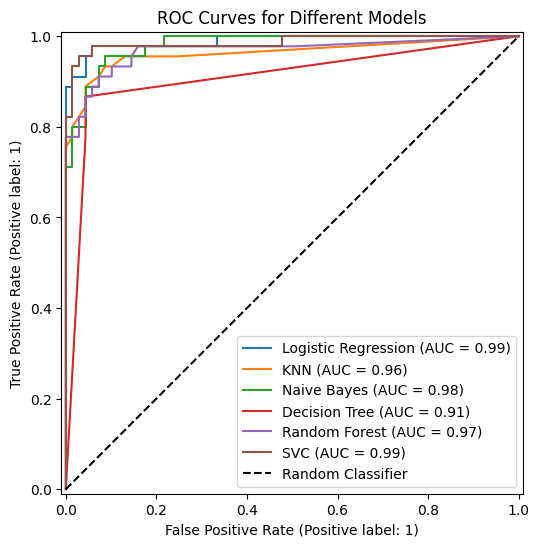

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))

RocCurveDisplay.from_estimator(logistic_regressor, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(knn_clf, X_test, y_test, ax=ax, name="KNN")
RocCurveDisplay.from_estimator(gnb_clf, X_test, y_test, ax=ax, name="Naive Bayes")
RocCurveDisplay.from_estimator(decision_tree, X_test, y_test, ax=ax, name="Decision Tree")
RocCurveDisplay.from_estimator(random_forest, X_test, y_test, ax=ax, name="Random Forest")
RocCurveDisplay.from_estimator(svc_model, X_test, y_test, ax=ax, name="SVC")

ax.set_title("ROC Curves for Different Models")
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Add random classifier line
ax.legend()
plt.show()

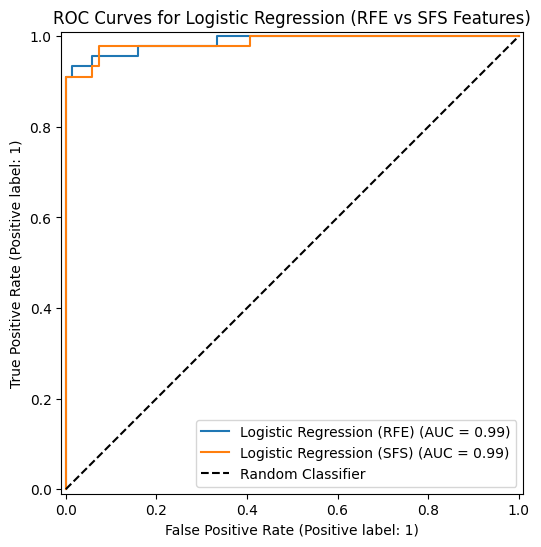

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt


logistic_regressor_rfe_for_plot = LogisticRegression(random_state=7890, max_iter=5000)
logistic_regressor_rfe_for_plot.fit(X_train[rfe_cv_features], y_train)

logistic_regressor_sfs_for_plot = LogisticRegression(random_state=7890, max_iter=5000)
logistic_regressor_sfs_for_plot.fit(X_train[sfs_features], y_train)

fig, ax = plt.subplots(figsize=(8,6))

RocCurveDisplay.from_estimator(logistic_regressor_rfe_for_plot, X_test[rfe_cv_features], y_test, ax=ax, name="Logistic Regression (RFE)")
RocCurveDisplay.from_estimator(logistic_regressor_sfs_for_plot, X_test[sfs_features], y_test, ax=ax, name="Logistic Regression (SFS)")

ax.set_title("ROC Curves for Logistic Regression (RFE vs SFS Features)")
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Add random classifier line
ax.legend()
plt.show()

## 8.Conusion matrix

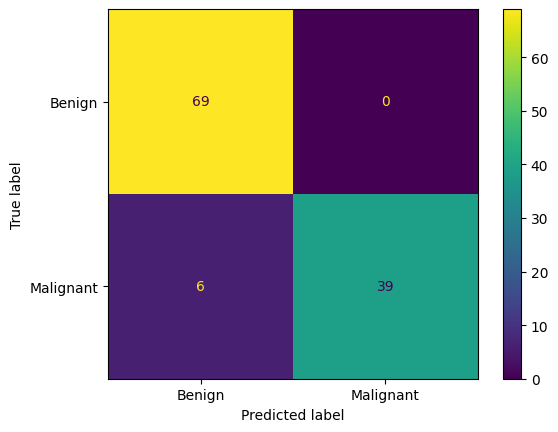

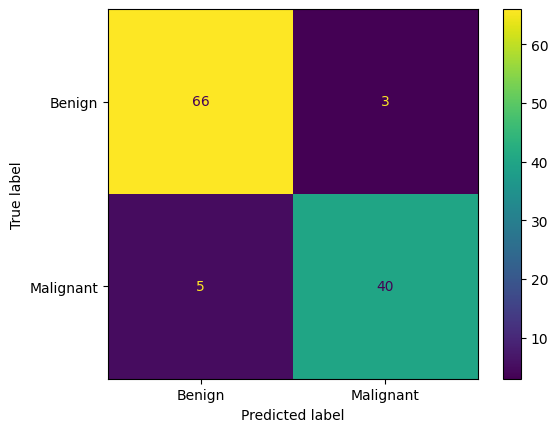

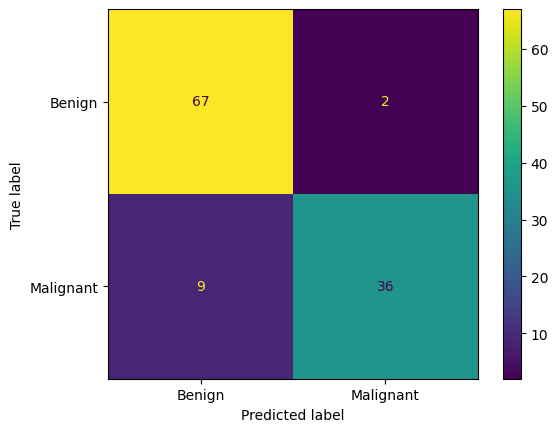

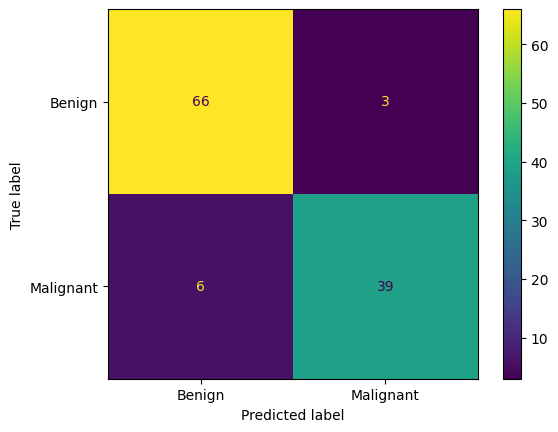

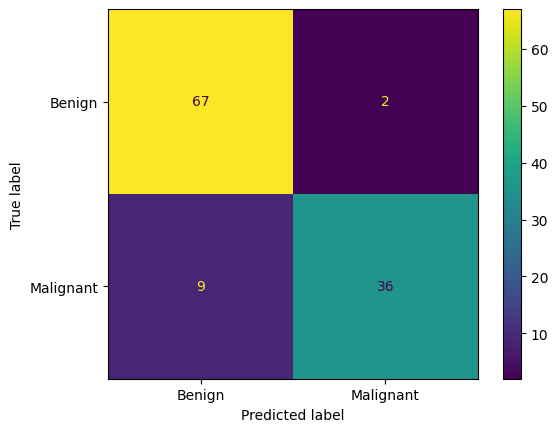

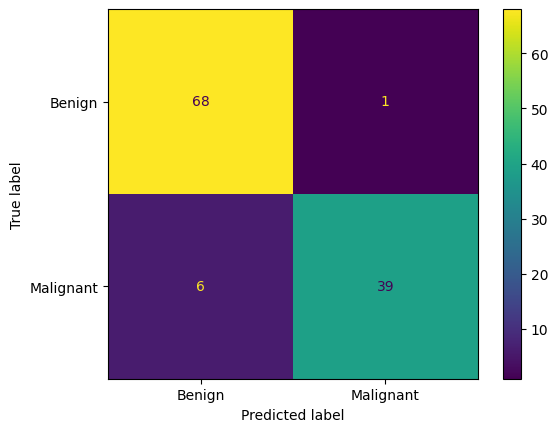

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#logstic regression
y_test_pred_1 = logistic_regressor.predict(X_test)
cm_1 = confusion_matrix(y_test, y_test_pred_1)
display = ConfusionMatrixDisplay(cm_1, display_labels=['Benign', 'Malignant'])
display.plot()

#KNN classifier
y_test_pred_2 = knn_clf.predict(X_test)
cm_2 = confusion_matrix(y_test, y_test_pred_2)
display = ConfusionMatrixDisplay(cm_2, display_labels=['Benign', 'Malignant'])
display.plot()

#Naive Bayes Classifier
y_test_pred_3 = gnb_clf.predict(X_test)
cm_3 = confusion_matrix(y_test, y_test_pred_3)
display = ConfusionMatrixDisplay(cm_3, display_labels=['Benign', 'Malignant'])
display.plot()

#dicision tree
y_test_pred_4 = decision_tree.predict(X_test)
cm_4 = confusion_matrix(y_test, y_test_pred_4)
display = ConfusionMatrixDisplay(cm_4, display_labels=['Benign', 'Malignant'])
display.plot()

#random forest
y_test_pred_5 = random_forest.predict(X_test)
cm_5 = confusion_matrix(y_test, y_test_pred_5)
display = ConfusionMatrixDisplay(cm_5, display_labels=['Benign', 'Malignant'])
display.plot()

#SVC
y_test_pred_6 = svc_model.predict(X_test)
cm_6 = confusion_matrix(y_test, y_test_pred_6)
display = ConfusionMatrixDisplay(cm_6, display_labels=['Benign', 'Malignant'])
display.plot()

## 資料故事（可供海報與錄製影片使用）
以上是藉由不同種類的監督是訓練方法來訓練資料。並繪製出ROC curve以及得到每一種方法的AUC值。
可以發現在六個方法中，羅吉斯回歸以及支援向量機的AUC值最高，可以初步判斷這兩種方法會有較強的分類能力。

然而，我就很好奇為什麼這兩種方法的AUC值都高達0.99?可以發現這兩種方法都是線性分隔。也許是因為這些乳癌的特徵都非常適合做線性區分，畢竟都是數值型資料。也導致像是二分法的decision tree分類效能就會比較差。

但我認為做醫療分析，並不能只單看機器的分類強度。其中accuracy也是非常重要的指標，這能夠幫助我們發現哪一個模型能夠準確的學習並分析測試資料。結果顯示，仍舊是羅吉斯回歸以高達0.94的正確率取得第一。或許，這個資料真的非常適合以線性模型作為分析的工具。

此外，我想倘若以後要將機器學習深入診療之中，將惡性病人判成良性是非常致命的。在此模型中，根據confusion matrix，表現最好的是KNN，僅誤判了5人。然而，此樣本仍舊過少，數據接近的前提下也無法斷言哪個模型最能夠降低惡性判成良性的比率。

以上除了得知哪種模型的效能最好，我們也能從Random Forest的方法中看出哪個特徵會對隨機叢林最具重要性。

圖表指出concave points_mean, concave points_worst分據一二名，因此可以判斷出concave points對Random Forest的機器學習法影響頗大。然後接下來perimeter_worst,
area_worst, radius_worst，這三個資料特徵都代表腫瘤大小。可以知道，最大顆的腫瘤大小對於腫瘤之良性惡性影響很大。基本上越大顆，越趨於惡性。

除了random forest，後續我們也會用其他模型來探討再各個機器學習法中特徵的重要程度。

# 二、model interpretation

## 1.資料相關性

Text(0.5, 1.02, '2D Hierarchical Clustering of Feature Correlations')

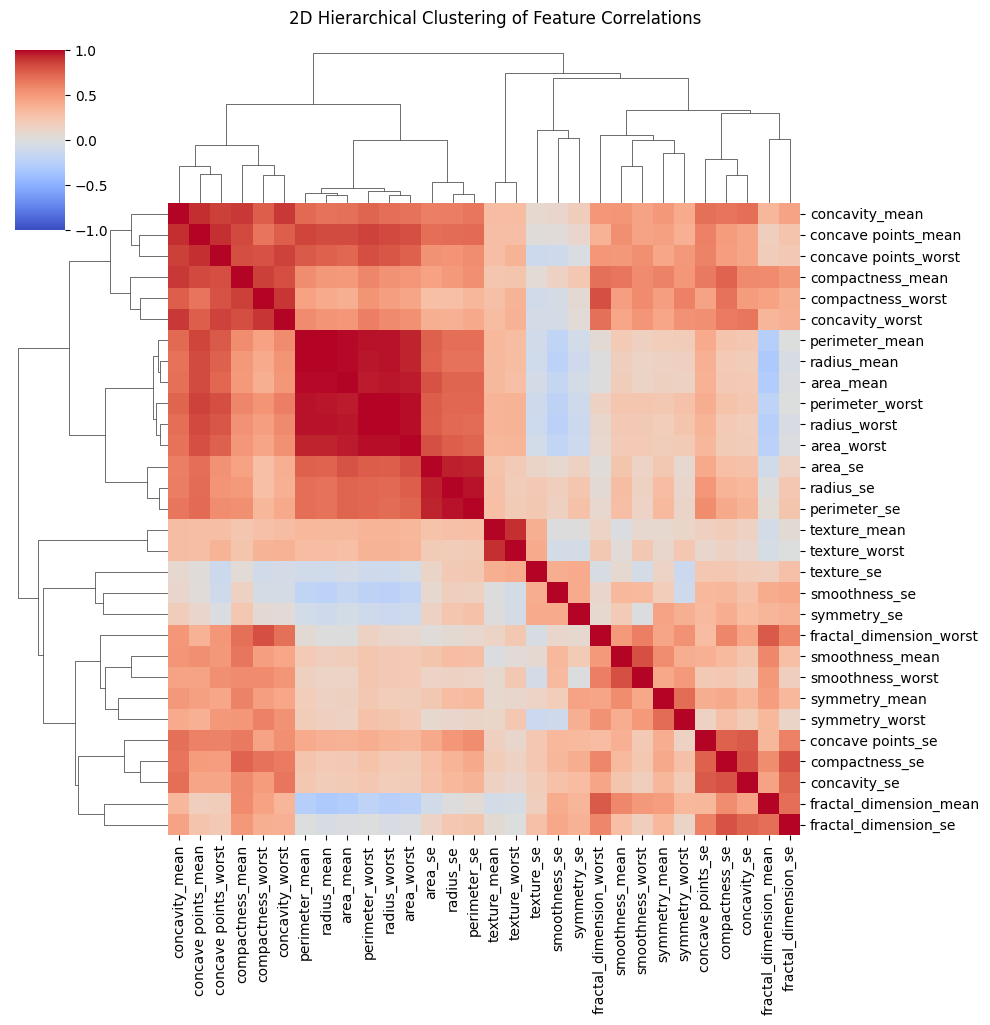

In [ ]:
correlation_matrix = X.corr()
clust_map = sns.clustermap(
    correlation_matrix,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    linewidths=0.0,
)
clust_map.fig.suptitle("2D Hierarchical Clustering of Feature Correlations", y=1.02)

##2.SHAP

In [ ]:
#這裡以Logistic Regression作為訓練的模型

import shap
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=100, random_state=1234)
classifier.fit(X_train, y_train)
clf_explainer = shap.Explainer(classifier, X_train)
clf_shap_values = clf_explainer(X_test)

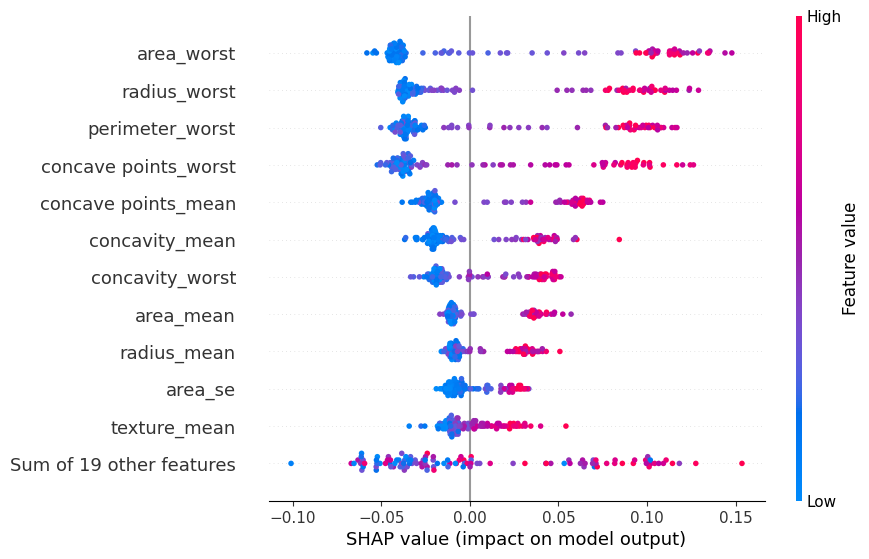

In [ ]:
#每一個特徵對惡性腫瘤的貢獻度
shap.plots.beeswarm(shap_values=clf_shap_values[:, :, 1], max_display=12)

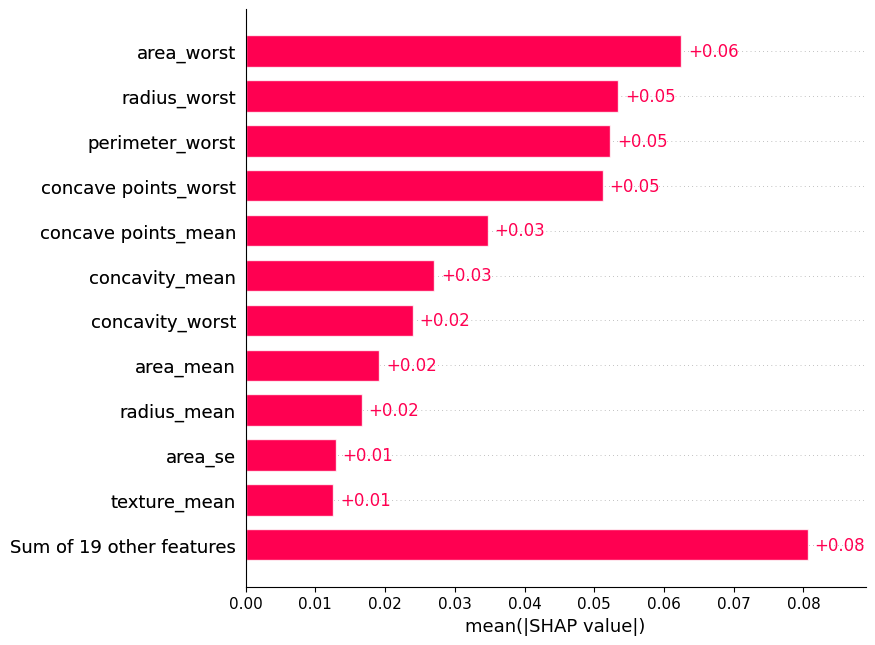

In [ ]:
shap.plots.bar(shap_values=clf_shap_values[:, :, 1], max_display=12)

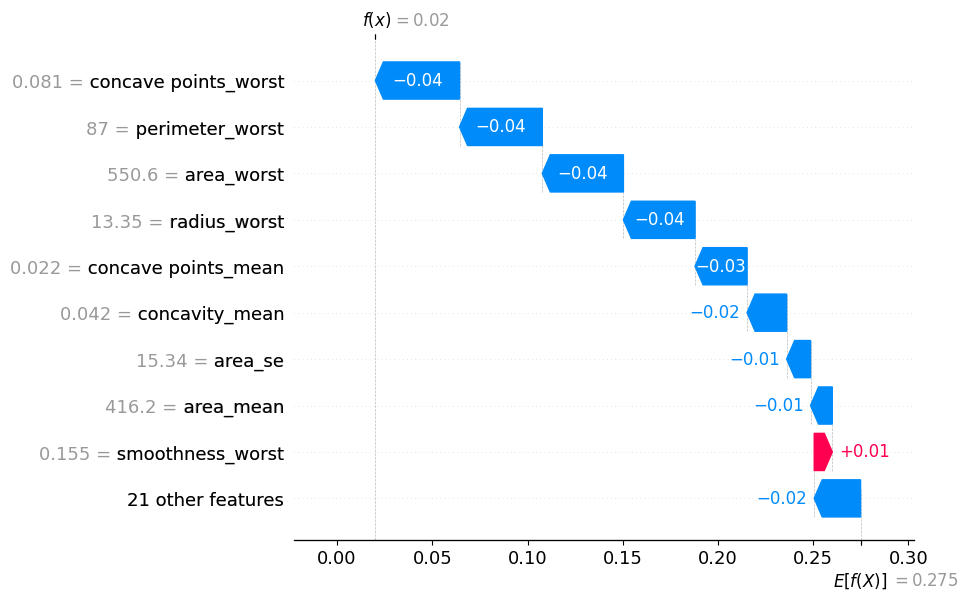

In [ ]:
#會這樣的原因是我們一開始把資料倒轉了(原本惡性為0，我們改成1)，所以這仍是影響惡性特徵的貢獻度
shap.plots.waterfall(clf_shap_values[0, :, 1])

In [ ]:
shap.initjs()
force_plot = shap.plots.force(clf_shap_values[0, :, 1])
force_plot

## 3.Learning curve

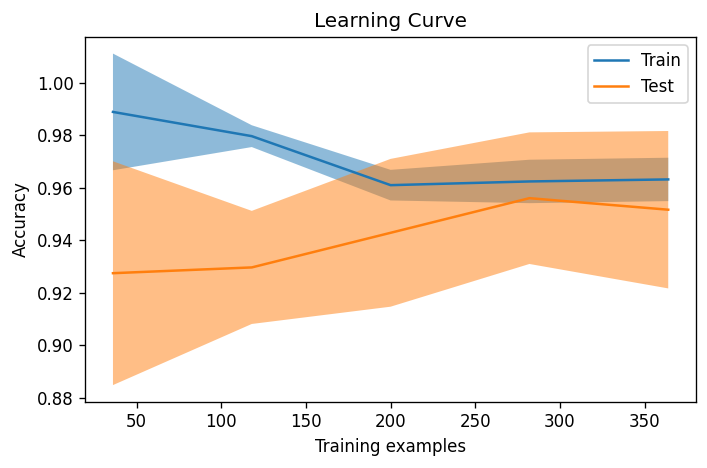

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
from sklearn.model_selection import LearningCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


classifier = LogisticRegression(max_iter=5000, random_state=1234)

LearningCurveDisplay.from_estimator(
    estimator=classifier,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    shuffle=True,
    random_state=4321,
    ax=ax,
)

ax.set_title("Learning Curve")
ax.set_xlabel("Training examples")
ax.set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

# 三、非監督式學習

# Data Preprocessing

In [ ]:
# Remove ID column if it exists
if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)

# Remove unnamed column if it exists
if 'Unnamed: 32' in df.columns:
    df.drop(columns=['Unnamed: 32'], inplace=True)

# Save diagnosis labels
y = df['diagnosis']

# Remove diagnosis column
X = df.drop(columns=['diagnosis'])

# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Preprocessing completed.")
print("Data shape:", X_scaled.shape)

Preprocessing completed.
Data shape: (569, 30)


# 1.Correlation Heatmap

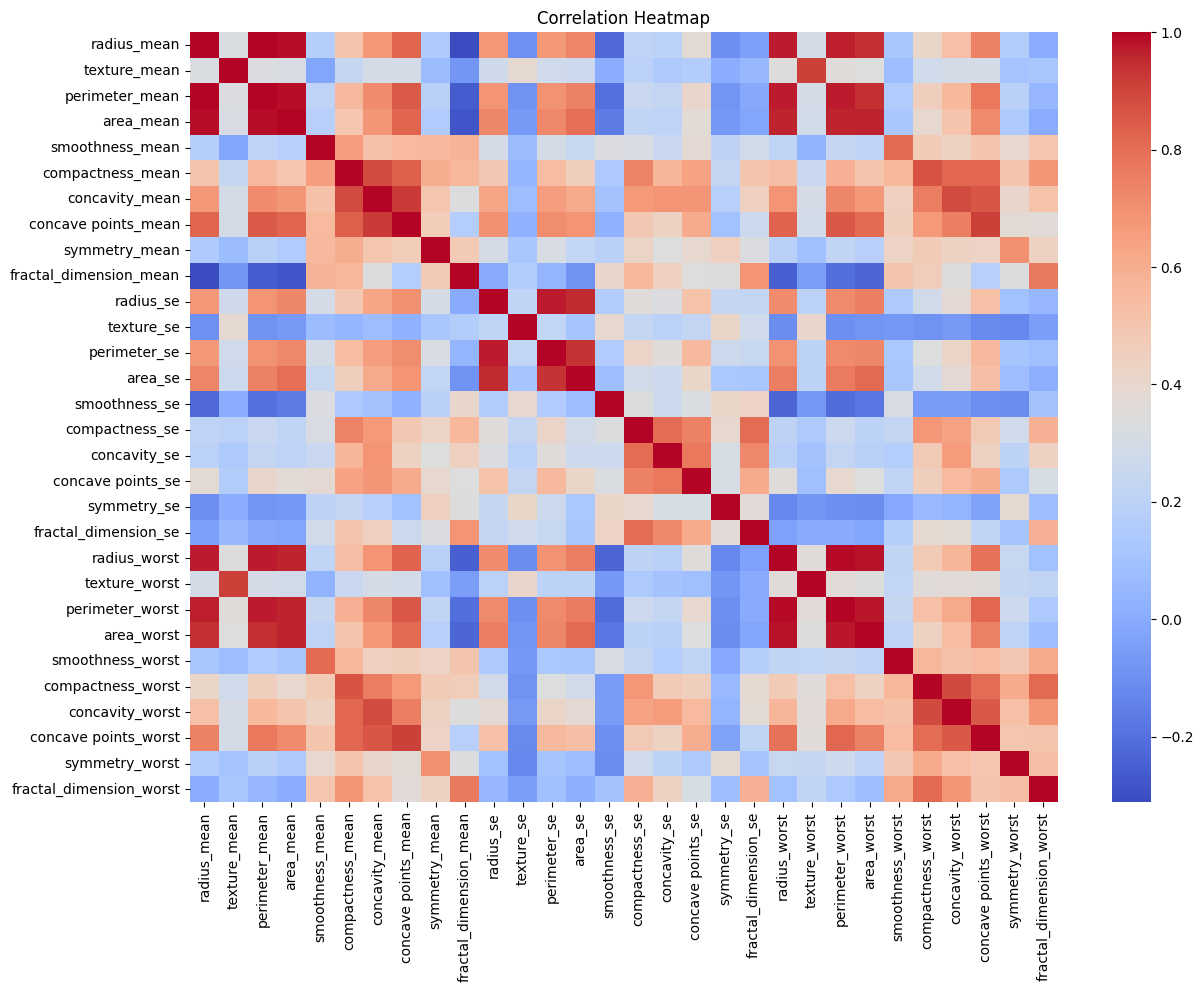

In [ ]:
# Create correlation matrix visualization
plt.figure(figsize=(14,10))

sns.heatmap(
    X.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

根據Correlation heatmap結果，我們發現乳癌資料中的特徵並非彼此獨立，而是存在明顯的群組相關性。
由於資料中存在高度相關的特徵，代表部分變數資訊具有冗餘性，因此有必要透過降維方法來減少維度並萃取主要變異來源，以提升後續分析的穩定性與可解釋性。

# 2.PCA

\nExplained Variance Ratio:
[0.44272026 0.18971182]


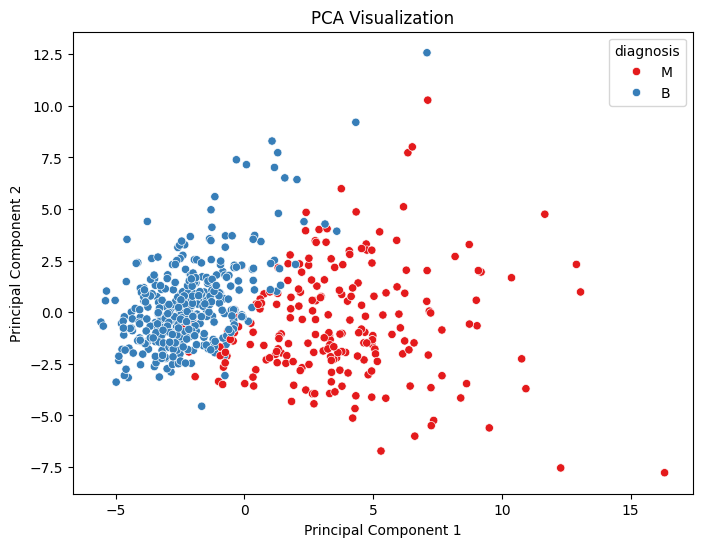

In [ ]:
# Reduce high-dimensional data into 2 dimensions
pca = PCA(n_components=2)

# Fit and transform the data
X_pca = pca.fit_transform(X_scaled)

# Display explained variance ratio
print("\\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Visualize PCA result
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette='Set1'
)

plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

# PCA Loading Analysis

In [ ]:
loading = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

print(
    loading["PC1"]
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

concave points_mean     0.260854
concavity_mean          0.258400
concave points_worst    0.250886
compactness_mean        0.239285
perimeter_worst         0.236640
concavity_worst         0.228768
radius_worst            0.227997
perimeter_mean          0.227537
area_worst              0.224871
area_mean               0.220995
Name: PC1, dtype: float64


我們利用PCA Loading分析各特徵對資料分布的貢獻程度。
結果顯示，第一主成分(PC1)中最重要的特徵依序為concave points_mean、concavity_mean、concave points_worst、compactness_mean與perimeter_worst等變數。其中，concave points與concavity相關特徵皆與腫瘤邊緣的凹陷程度及形狀不規則性有關，表示腫瘤形態特徵是造成資料差異的主要來源。
此外，radius_worst、perimeter_mean、perimeter_worst、area_mean與area_worst 等特徵也具有較高的重要性，這些特徵皆與腫瘤大小相關。結果顯示腫瘤尺寸同樣是影響資料分群的重要因素之一。
綜合PCA分析結果可以發現，乳癌資料的主要變異來源可歸因於「腫瘤形狀不規則程度」以及「腫瘤大小」兩大面向。其中，形狀不規則相關特徵的重要性高於腫瘤大小特徵，顯示腫瘤邊界結構可能比單純的尺寸更能反映腫瘤之間的差異。
因此，即使在未提供良性或惡性標籤的情況下，非監督式學習方法仍能根據這些特徵，自動發現資料中的潛在結構與群體差異。

# 3.t-SNE

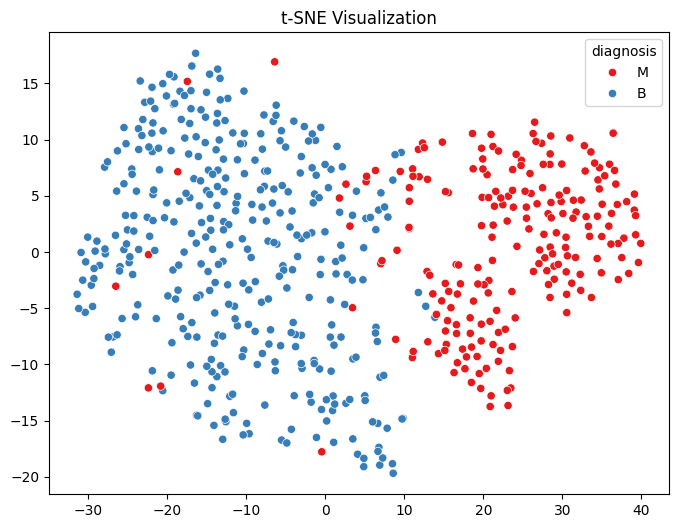

In [ ]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

# Transform data
X_tsne = tsne.fit_transform(X_scaled)

# Visualize t-SNE result
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=y,
    palette='Set1'
)

plt.title("t-SNE Visualization")

plt.show()

t-SNE的視覺化結果顯示，相較於PCA，資料點之間的群集分布更為明顯，呈現出較清楚的分群趨勢。此結果表示乳癌資料中確實存在潛在的局部結構，即使未使用診斷標籤，資料仍可能自然形成具有區隔性的群體。

# 4.KMeans Clustering

\nSilhouette Score:
0.3447344346611054


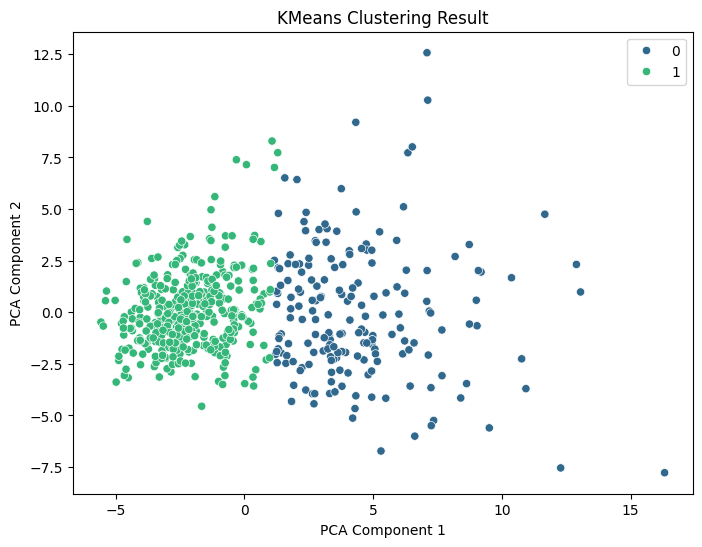

In [ ]:
# Create KMeans model
# Use K = 2 because there are two cancer types
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

# Train model and predict clusters
clusters = kmeans.fit_predict(X_scaled)

# Calculate silhouette score
score = silhouette_score(X_scaled, clusters)

print("\\nSilhouette Score:")
print(score)

# Visualize clustering result in PCA space
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters,
    palette='viridis'
)

plt.title("KMeans Clustering Result")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

由於 Breast Cancer Wisconsin Dataset 的診斷結果可分為良性(Benign)與惡性(Malignant)兩類，因此我們將群數設定為K=2，以探討非監督式學習是否能在未使用診斷標籤的情況下，自動辨識資料中的潛在群體。
K-Means 分群結果顯示，資料可被區分為兩個主要群集，且在PCA視覺化空間中呈現相對明顯的分離現象。雖然模型在訓練過程中並未使用diagnosis標籤，但最終形成的群集仍與資料本身的特徵分布具有一致性，顯示乳癌資料中存在明顯的自然分群結構。
此結果說明，腫瘤形態與大小等特徵已足以使模型自動辨識不同類型的樣本，而不需要依賴人工標註的診斷結果。

# 5.Hierarchical Clustering

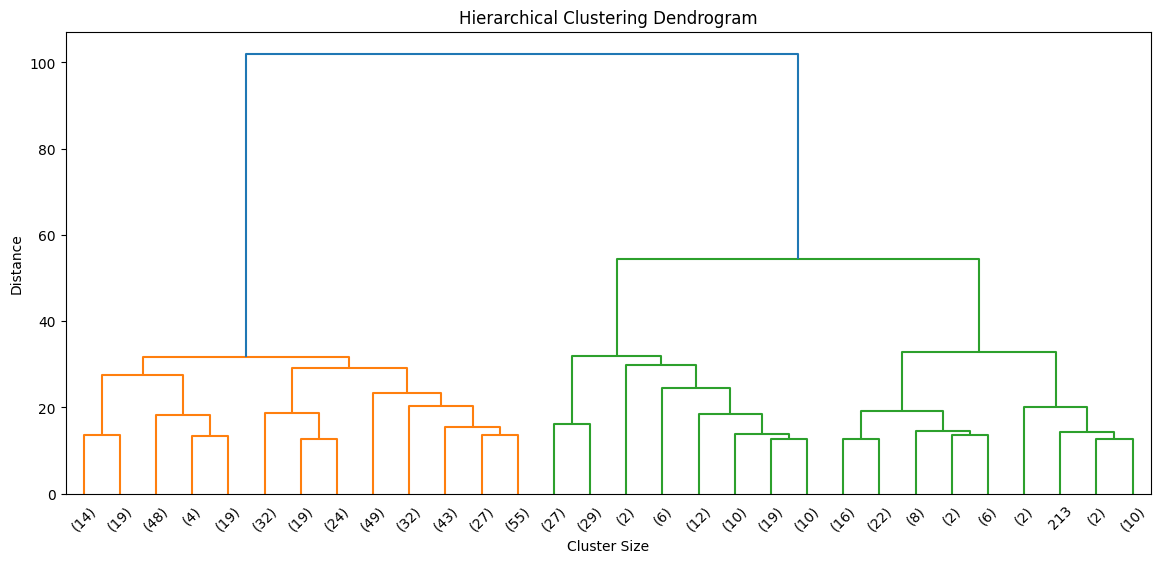

In [ ]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14,6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")

plt.show()

結果顯示，dendrogram中資料逐步形成數個明顯的群集結構，且部分群體需在較高的距離下才會被合併，表示不同群集之間具有較高的差異性，顯示資料本身確實存在穩定且一致的內在結構。

# 6.Compare Clusters with Diagnosis

In [ ]:
comparison = pd.DataFrame({
    'Actual Diagnosis': y,
    'Cluster': clusters
})

print("\\nCluster Comparison Table:")

# Cross-tabulation
print(
    pd.crosstab(
        comparison['Actual Diagnosis'],
        comparison['Cluster']
    )
)

\nCluster Comparison Table:
Cluster             0    1
Actual Diagnosis          
B                  13  344
M                 175   37


從結果可以觀察到，Cluster 1主要對應於良性腫瘤(344 筆)，而Cluster 0則多數對應於惡性腫瘤(175 筆)，顯示模型能夠在未使用標籤的情況下，有效區分不同類型的腫瘤樣本。
雖然仍存在部分錯分情況，但整體而言，分群結果與實際診斷具有明顯對應關係，顯示資料本身具有清楚的內在結構。